Epoch 1/30
29/29 [==============================] - 59s 2s/step - loss: 1.4729 - accuracy: 0.3861 - val_loss: 1.3540 - val_accuracy: 0.5357 - lr: 1.0000e-04
Epoch 2/30
29/29 [==============================] - 51s 2s/step - loss: 1.3061 - accuracy: 0.4653 - val_loss: 1.2333 - val_accuracy: 0.5500 - lr: 1.0000e-04
Epoch 3/30
29/29 [==============================] - 51s 2s/step - loss: 1.2176 - accuracy: 0.5369 - val_loss: 1.1529 - val_accuracy: 0.6357 - lr: 1.0000e-04
Epoch 4/30
29/29 [==============================] - 51s 2s/step - loss: 1.1578 - accuracy: 0.6063 - val_loss: 1.0948 - val_accuracy: 0.6857 - lr: 1.0000e-04
Epoch 5/30
29/29 [==============================] - 51s 2s/step - loss: 1.1096 - accuracy: 0.6101 - val_loss: 1.0454 - val_accuracy: 0.7286 - lr: 1.0000e-04
Epoch 6/30
29/29 [==============================] - 51s 2s/step - loss: 1.0584 - accuracy: 0.6649 - val_loss: 0.9925 - val_accuracy: 0.7571 - lr: 1.0000e-04
Epoch 7/30
29/29 [==============================] - 53s 2s

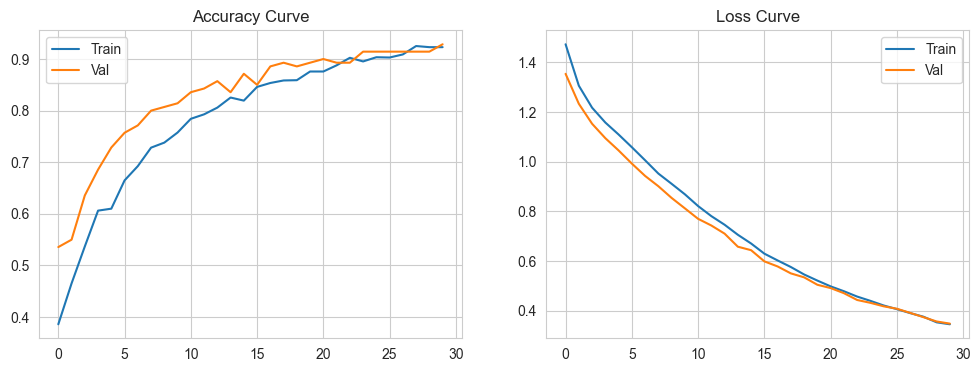

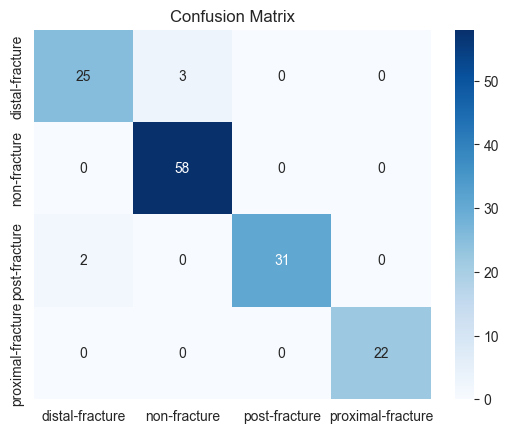


Classification Report:

                   precision    recall  f1-score   support

  distal-fracture       0.93      0.89      0.91        28
     non-fracture       0.95      1.00      0.97        58
    post-fracture       1.00      0.94      0.97        33
proximal-fracture       1.00      1.00      1.00        22

         accuracy                           0.96       141
        macro avg       0.97      0.96      0.96       141
     weighted avg       0.97      0.96      0.96       141

Weighted F1: 0.9642631956070629
Cohen Kappa: 0.9499289772727273


In [1]:
# -------------------- PROTOBUF FIX --------------------
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

# -------------------- IMPORTS --------------------
import random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, cohen_kappa_score
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# -------------------- GLOBAL CONFIG --------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (520,520)   # consistent size
BATCH_SIZE = 64
EPOCHS = 30
NUM_CLASSES = 4

CLASS_NAMES = [
    'distal-fracture',
    'non-fracture',
    'post-fracture',
    'proximal-fracture'
]

BASE_DIR = Path(r"F:\Main data")
CSV_PATH = BASE_DIR / "bone_metadata.csv"

# -------------------- LOAD IMAGES --------------------
IMG_DIR_MAP = {c:c for c in CLASS_NAMES}
image_paths, labels = [], []
for cls in CLASS_NAMES:
    for ext in ['*.jpg','*.png','*.jpeg']:
        for img in (BASE_DIR / IMG_DIR_MAP[cls]).glob(ext):
            image_paths.append(str(img))
            labels.append(cls)

img_df = pd.DataFrame({"image_path": image_paths,"fracture_type": labels})

# -------------------- LOAD METADATA --------------------
df = pd.read_csv(CSV_PATH)
df['id_clean'] = df['id'].astype(str)
img_df['id_clean'] = img_df['image_path'].apply(lambda x: Path(x).stem)

merged_df = img_df.merge(df, on='id_clean', how='left')
merged_df.dropna(subset=['age','primary_observation'], inplace=True)

# -------------------- PREPROCESS --------------------
categorical_cols = ['gender','bone_type','left_right','gap_visibility','primary_observation']
numerical_cols = ['age','bone_width','fracture_gap']

label_encoders = {}
for col in categorical_cols:
    merged_df[col] = merged_df[col].fillna("unknown")
    le = LabelEncoder()
    merged_df[col+"_encoded"] = le.fit_transform(merged_df[col])
    label_encoders[col] = le

# Ensure numeric conversion and float dtype
for col in numerical_cols:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    merged_df[col].fillna(merged_df[col].median(), inplace=True)
merged_df[numerical_cols] = merged_df[numerical_cols].astype(float)

scaler = StandardScaler()
merged_df[numerical_cols] = scaler.fit_transform(merged_df[numerical_cols])

metadata_cols = [c+"_encoded" for c in categorical_cols] + numerical_cols

X_images = merged_df['image_path'].values
X_meta = merged_df[metadata_cols].values

# -------------------- TARGET --------------------
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(merged_df['fracture_type'])

# -------------------- SPLIT --------------------
X_img_tr, X_img_tmp, X_meta_tr, X_meta_tmp, y_tr, y_tmp = train_test_split(
    X_images, X_meta, y, test_size=0.2, stratify=y, random_state=SEED
)
X_img_val, X_img_te, X_meta_val, X_meta_te, y_val, y_te = train_test_split(
    X_img_tmp, X_meta_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED
)

# -------------------- OVERSAMPLING --------------------
unique, counts = np.unique(y_tr, return_counts=True)
max_count = counts.max()
idxs = []
for c in unique:
    ids = np.where(y_tr==c)[0]
    ids = np.random.choice(ids, max_count, replace=True)
    idxs.append(ids)
idxs = np.concatenate(idxs)
np.random.shuffle(idxs)

X_img_tr, X_meta_tr, y_tr = X_img_tr[idxs], X_meta_tr[idxs], y_tr[idxs]

y_tr_cat = keras.utils.to_categorical(y_tr, NUM_CLASSES)
y_val_cat = keras.utils.to_categorical(y_val, NUM_CLASSES)
y_te_cat  = keras.utils.to_categorical(y_te, NUM_CLASSES)

# -------------------- DATA GENERATOR --------------------
class Gen(keras.utils.Sequence):
    def __init__(self, imgs, meta, labels, batch):
        self.imgs, self.meta, self.labels = imgs, meta, labels
        self.batch = batch
        self.idx = np.arange(len(imgs))
    def __len__(self):
        return int(np.ceil(len(self.imgs)/self.batch))
    def __getitem__(self,i):
        ids = self.idx[i*self.batch:(i+1)*self.batch]
        X1,X2,y = [],[],[]
        for j in ids:
            img = cv2.imread(self.imgs[j], cv2.IMREAD_GRAYSCALE)
            img = cv2.createCLAHE(3,(8,8)).apply(img)
            img = cv2.resize(img, IMG_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)/255.0
            X1.append(img)
            X2.append(self.meta[j])
            y.append(self.labels[j])
        return [np.array(X1),np.array(X2)],np.array(y)

train_gen = Gen(X_img_tr,X_meta_tr,y_tr_cat,BATCH_SIZE)
val_gen   = Gen(X_img_val,X_meta_val,y_val_cat,BATCH_SIZE)
test_gen  = Gen(X_img_te,X_meta_te,y_te_cat,BATCH_SIZE)

# -------------------- MODEL --------------------
img_in = layers.Input((IMG_SIZE[0], IMG_SIZE[1], 3))  # match IMG_SIZE
x = layers.Conv2D(32,3,padding='same',activation='relu')(img_in)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,3,padding='same',activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)

meta_in = layers.Input((X_meta_tr.shape[1],))
m = layers.Dense(64,activation='relu')(meta_in)

f = layers.Concatenate()([x,m])
f = layers.Dense(128,activation='relu')(f)
out = layers.Dense(NUM_CLASSES,activation='softmax')(f)

model = Model([img_in,meta_in],out)
model.compile(Adam(1e-4),'categorical_crossentropy',['accuracy'])

# -------------------- TRAIN --------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(patience=3,factor=0.4),
        keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)
    ]
).history

# -------------------- EVALUATION --------------------
y_prob = model.predict(test_gen)
y_pred = np.argmax(y_prob,1)
y_true = y_te

# ---- Accuracy & Loss Curves ----
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['accuracy']); plt.plot(history['val_accuracy'])
plt.title("Accuracy Curve"); plt.legend(['Train','Val'])

plt.subplot(1,2,2)
plt.plot(history['loss']); plt.plot(history['val_loss'])
plt.title("Loss Curve"); plt.legend(['Train','Val'])
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.show()

# ---- Classification Report ----
print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,target_names=CLASS_NAMES))

# ---- Extra Metrics ----
print("Weighted F1:", f1_score(y_true,y_pred,average='weighted'))
print("Cohen Kappa:", cohen_kappa_score(y_true,y_pred))
